**LAB EXPERIMENT - 7**

**Clustering using K-Means and Gaussian Mixture Models (GMM)**

Name : Poovika M\
Roll No : 24BAD087

**SCENARIO 1**

**CODE INTERPRETATION**


*   Libraries imported for data handling, visualization, clustering, preprocessing, and evaluation

*   Mall Customer dataset loaded using read_csv()

*   Checked for missing values using isnull().sum()

*   Relevant features selected: Annual Income and Spending Score

*   Data preprocessing performed using StandardScaler for feature scaling

*   Elbow Method applied to determine optimal number of clusters (K)

*   Inertia values calculated for different K values (1 to 10)

*   Elbow curve plotted to identify optimal K

*   Optimal number of clusters chosen as K = 5

*   K-Means algorithm applied to scaled data

*   Cluster labels assigned to each data point

*   Cluster labels added as a new column in the dataset

*  Silhouette Score calculated to evaluate clustering quality

*   Cluster centroids obtained in scaled form

*   Centroids transformed back to original scale for interpretation

*   Scatter plot generated to visualize clusters

*  Cluster centroids plotted along with data points

*   Clusters represent customer segments based on income and spending behavior

*   K-Means groups similar data points by minimizing intra-cluster distance

*   Model performance analyzed using Inertia and Silhouette Score

*   Visualization helps in understanding cluster separation and compactness

*   K-Means effectively identifies distinct customer segments



POOVIKA M - 24BAD087
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


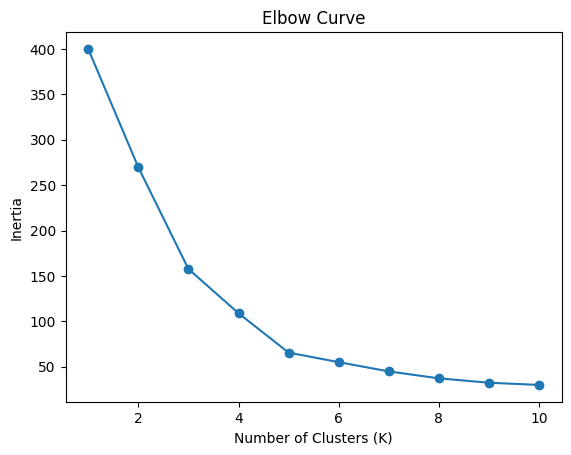

Silhouette Score: 0.5546571631111091
Centroids (Original Scale):
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


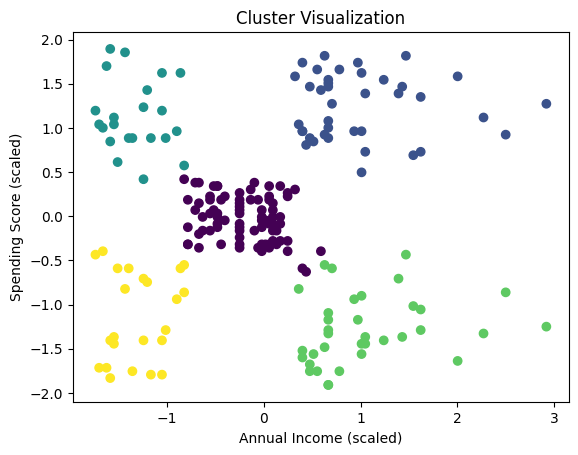

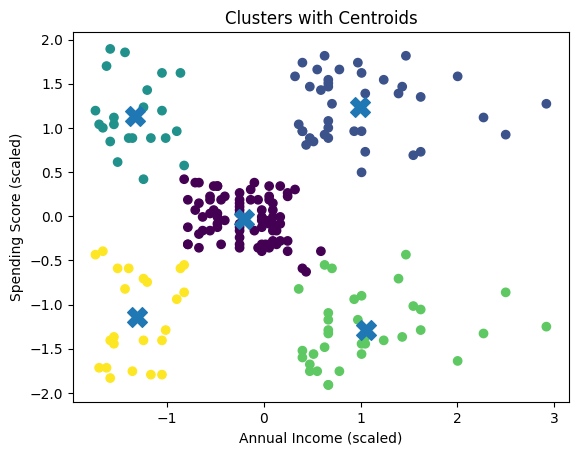

In [2]:
# Import required libraries
print("POOVIKA M - 24BAD087")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load dataset
data = pd.read_csv("/content/sample_data/Mall_Customers.csv")

# Check missing values
print(data.isnull().sum())

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method (K vs Inertia)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()

# Apply K-Means (choose optimal K = 5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
data['Cluster'] = clusters

# Silhouette Score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

# Cluster Centroids
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

print("Centroids (Original Scale):")
print(centroids)

# Scatter Plot of Clusters
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Cluster Visualization")
plt.show()

# Scatter Plot with Centroids
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], marker='X', s=200)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Clusters with Centroids")
plt.show()

**SCENARIO 2**

**CODE INTERPRETATION**


*   Libraries imported for data handling, visualization, clustering, preprocessing, and evaluation

*   Mall Customer dataset loaded using read_csv()

*   Relevant features selected: Annual Income and Spending Score

*   Data preprocessing performed using StandardScaler for feature scaling

*   Gaussian Mixture Model (GMM) used for probabilistic clustering

*   AIC and BIC scores computed for different numbers of components (1 to 10)

*   AIC and BIC plots generated to determine optimal number of clusters

*   Optimal number of components chosen as K = 5 based on graph

*   GMM model fitted using Expectation-Maximization (EM) algorithm

*   Cluster probabilities predicted for each data point

*   Cluster labels assigned based on highest probability

*   Cluster labels added to dataset as a new column

*   Log-Likelihood calculated to measure model fit
*   AIC and BIC used to evaluate model complexity and goodness of fit


*   Silhouette Score calculated to evaluate clustering quality

*   K-Means clustering applied for comparison with GMM

*   Silhouette Score of K-Means computed and compared with GMM

*   Histogram plotted to show distribution of maximum cluster probabilities

*   GMM contour plot generated to visualize probabilistic cluster boundaries

*   Scatter plot overlaid with contours to show cluster regions

*   Comparison plot created to visualize difference between K-Means and GMM

*   GMM shows soft clustering with overlapping clusters

*   K-Means shows hard clustering with clear boundaries

*   KDE plots generated to visualize probability distribution of each cluster

*   GMM captures complex, elliptical cluster shapes effectively

*   Model demonstrates flexibility compared to K-Means


POOVIKA M - 24BAD087


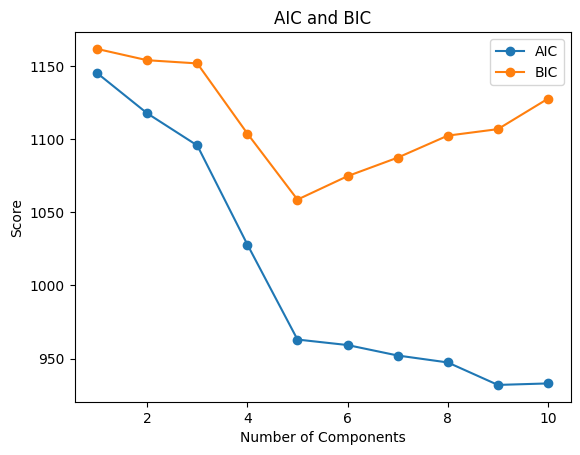

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245
Silhouette Score (K-Means): 0.5546571631111091


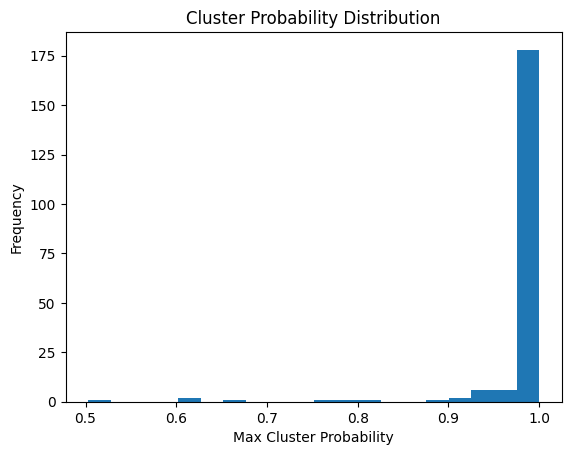

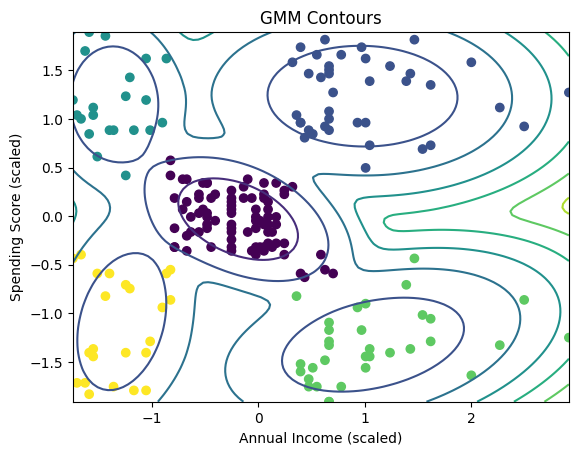

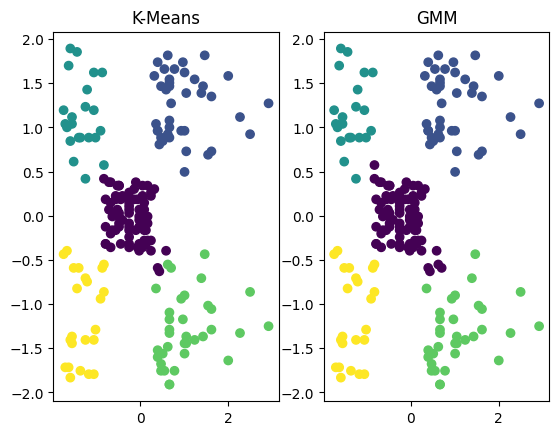

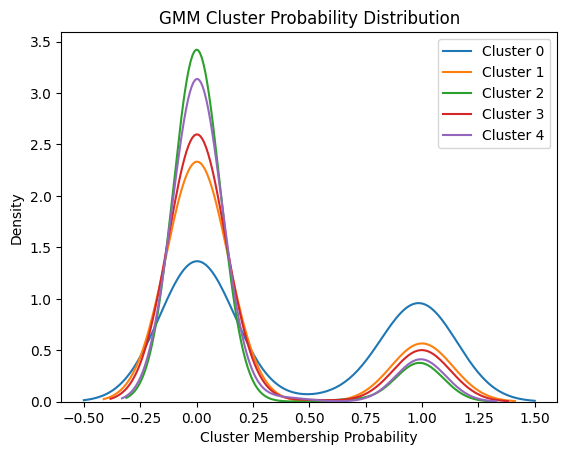

In [3]:
#POOVIKA M - 24BAD087
# Import required libraries
print("POOVIKA M - 24BAD087")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
data = pd.read_csv("/content/sample_data/Mall_Customers.csv")

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Choose number of components using AIC and BIC
aic = []
bic = []
K_range = range(1, 11)

for k in K_range:
    gmm_temp = GaussianMixture(n_components=k, random_state=42)
    gmm_temp.fit(X_scaled)
    aic.append(gmm_temp.aic(X_scaled))
    bic.append(gmm_temp.bic(X_scaled))

plt.figure()
plt.plot(K_range, aic, marker='o', label='AIC')
plt.plot(K_range, bic, marker='o', label='BIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("AIC and BIC")
plt.legend()
plt.show()

# Apply GMM with optimal K (choose based on graph, here k=5)
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Predict probabilities and clusters
probabilities = gmm.predict_proba(X_scaled)
clusters_gmm = np.argmax(probabilities, axis=1)
data['GMM_Cluster'] = clusters_gmm

# Evaluation metrics
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, clusters_gmm))

# Apply K-Means for comparison
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)
data['KMeans_Cluster'] = clusters_kmeans

print("Silhouette Score (K-Means):", silhouette_score(X_scaled, clusters_kmeans))

# Cluster Probability Distribution
plt.figure()
plt.hist(np.max(probabilities, axis=1), bins=20)
plt.xlabel("Max Cluster Probability")
plt.ylabel("Frequency")
plt.title("Cluster Probability Distribution")
plt.show()

# GMM Contour Plot
x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_gmm)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("GMM Contours")
plt.show()

# Comparison Plot (K-Means vs GMM)
plt.figure()

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_kmeans)
plt.title("K-Means")

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_gmm)
plt.title("GMM")

plt.show()

# GMM Distribution Curves for Each Cluster
prob = gmm.predict_proba(X_scaled)

plt.figure()

for i in range(prob.shape[1]):
    sns.kdeplot(prob[:, i], label="Cluster " + str(i))

plt.xlabel("Cluster Membership Probability")
plt.ylabel("Density")
plt.title("GMM Cluster Probability Distribution")
plt.legend()
plt.show()